In [1]:
!hostname

cpusrv86.scidom.de


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.solvers import linear
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

import time

In [3]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 2, 7, 11
x = jax.random.normal(rngs[0], (n_x, d))
y = jax.random.normal(rngs[1], (n_y, d)) + 0.5

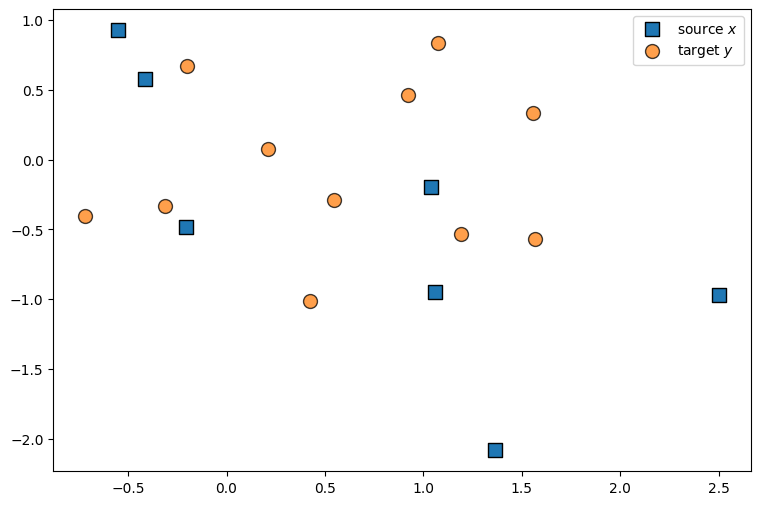

In [15]:
x_args = {"s": 100, "label": r"source $x$", "marker": "s", "edgecolor": "k"}
y_args = {"s": 100, "label": r"target $y$", "edgecolor": "k", "alpha": 0.75}
plt.figure(figsize=(9, 6))
plt.scatter(x[:, 0], x[:, 1], **x_args)
plt.scatter(y[:, 0], y[:, 1], **y_args)
plt.legend()
plt.show()

In [16]:
geom = pointcloud.PointCloud(x, y, cost_fn=None)

In [17]:
solve_fn = jax.jit(linear.solve)
ot = solve_fn(geom)

In [18]:
ot = solve_fn(geom)

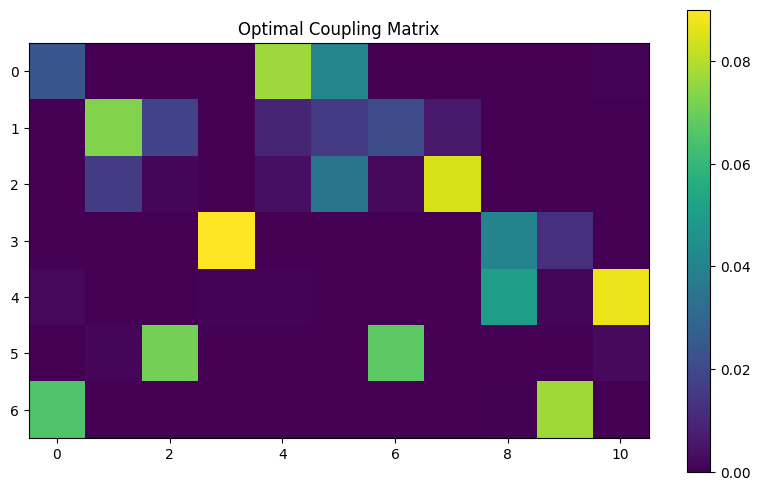

In [19]:
plt.figure(figsize=(10, 6))
plt.imshow(ot.matrix)
plt.colorbar()
plt.title("Optimal Coupling Matrix")
plt.show()

### Proof of principle for jitting: with larger vectors

#### 1. Try to jit `linear.solve`

In [9]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 500, 5000, 5000
x = jax.random.normal(rngs[0], (n_x, d))
y = jax.random.normal(rngs[1], (n_y, d)) + 0.5

In [10]:
geom = pointcloud.PointCloud(x, y, cost_fn=None)

In [11]:
solve_fn = jax.jit(linear.solve)
ot = solve_fn(geom)

In [12]:
# takes ca 2.3 seconds
ot.matrix

Array([[2.7647043e-22, 1.5179329e-25, 2.9210403e-33, ..., 1.0733534e-33,
        5.7318106e-25, 1.3037544e-06],
       [1.0440024e-27, 3.7838167e-32, 4.4281838e-26, ..., 9.0936717e-26,
        1.1159339e-15, 3.7811956e-22],
       [6.2326283e-33, 1.3269984e-25, 3.1030357e-31, ..., 2.0972336e-31,
        1.1401774e-22, 1.0163679e-30],
       ...,
       [1.3366999e-21, 1.7113601e-23, 4.3165690e-20, ..., 1.6135583e-25,
        6.4194651e-34, 1.4579053e-19],
       [2.4608783e-19, 6.1446952e-24, 4.0991986e-26, ..., 4.2676814e-34,
        8.5647393e-26, 6.6993674e-20],
       [2.4298112e-15, 1.7715072e-30, 8.7000501e-25, ..., 4.8242981e-12,
        1.3079331e-22, 2.0689640e-13]], dtype=float32)

In [14]:
x2 = jax.random.normal(rngs[0], (n_x, d))
y2 = jax.random.normal(rngs[1], (n_y, d)) + 0.6

In [15]:
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)

In [16]:
ot2 = solve_fn(geom2)

In [17]:
# not sure - is this faster than above? here takes ca 1.4 seconds
ot2.matrix

Array([[1.4152930e-21, 1.1656752e-24, 4.2142666e-32, ..., 1.8208773e-32,
        3.8271058e-24, 1.5331860e-06],
       [1.1072434e-26, 6.7501997e-31, 3.8971718e-25, ..., 8.7526454e-25,
        3.7043271e-15, 2.4574518e-21],
       [9.3035071e-32, 1.0638239e-24, 3.8179225e-30, ..., 2.9572026e-30,
        6.3229698e-22, 1.2863155e-29],
       ...,
       [6.5443981e-21, 1.1007852e-22, 1.7740870e-19, ..., 1.2656904e-24,
        1.0438962e-32, 6.1556434e-19],
       [9.4186962e-19, 4.0186159e-23, 2.9427159e-25, ..., 7.4916466e-33,
        6.1666948e-25, 2.8461331e-19],
       [6.3659507e-15, 2.2037274e-29, 5.5381554e-24, ..., 1.0056024e-11,
        6.9738374e-22, 4.7236818e-13]], dtype=float32)

#### 2. Try to jit both pointcloud and solver (claude suggestion)
Can see difference only for large datasets (which is not unexpected; small dataset is compilation overhead bigger than speed gain..)

In [18]:
# Generate data
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 1000, 20000, 10000
x = jax.random.normal(rngs[0], (n_x, d))
y = jax.random.normal(rngs[1], (n_y, d)) + 0.5

# Create a JIT-compiled function that takes the points as input
@jax.jit
def solve_ot(x, y):
    geom = pointcloud.PointCloud(x, y, cost_fn=None)
    return linear.solve(geom)

# First call (includes compilation time)
start = time.time()
ot = solve_ot(x, y)
ot.matrix.block_until_ready()
print(f"Time taken for first solve (with compilation): {time.time() - start:.2f} seconds")

# Second call (should be faster)
start = time.time()
ot = solve_ot(x, y)
ot.matrix.block_until_ready()
print(f"Time taken for second solve (after compilation): {time.time() - start:.2f} seconds")

# Test with different data but same shapes
x2 = jax.random.normal(rngs[0], (n_x, d))
y2 = jax.random.normal(rngs[1], (n_y, d)) + 0.6

start = time.time()
ot2 = solve_ot(x2, y2)
ot2.matrix.block_until_ready()
print(f"Time taken for third solve (different data, same shapes): {time.time() - start:.2f} seconds")

Time taken for first solve (with compilation): 36.37 seconds
Time taken for second solve (after compilation): 35.62 seconds
Time taken for third solve (different data, same shapes): 35.81 seconds


#### 3. Just jit linear.solve, with more data
I think see a difference - not a "blazing" 10x one, but a difference.

In [19]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 1000, 20000, 10000
x = jax.random.normal(rngs[0], (n_x, d))
y = jax.random.normal(rngs[1], (n_y, d)) + 0.5

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)

# Time the solve with explicit JIT
solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(geom)
ot.matrix.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = linear.solve(geom)
ot.matrix.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = jax.random.normal(rngs[0], (n_x, d))
y2 = jax.random.normal(rngs[1], (n_y, d)) + 0.6
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(geom2)
ot2.matrix.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")

Time with explicit JIT: 38.69 seconds
Time without JIT: 44.28 seconds
Time with new geometry: 36.19 seconds


In [20]:
from ott.problems.linear.linear_problem import LinearProblem
from ott.solvers.linear import sinkhorn

In [21]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 1000, 20000, 10000
x = jax.random.normal(rngs[0], (n_x, d))
y = jax.random.normal(rngs[1], (n_y, d)) + 0.5

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)
prob = LinearProblem(geom)

solver = sinkhorn.Sinkhorn()
solve_fn = jax.jit(solver)

# Time the solve with explicit JIT
# solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(prob)
ot.matrix.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = solver(prob)
ot.matrix.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = jax.random.normal(rngs[0], (n_x, d))
y2 = jax.random.normal(rngs[1], (n_y, d)) + 0.6
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)
prob2 = LinearProblem(geom2)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(prob2)
ot2.matrix.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")

Time with explicit JIT: 35.93 seconds
Time without JIT: 42.18 seconds
Time with new geometry: 35.69 seconds


Numpy arrays?


In [24]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 1000, 20000, 10000
x = np.array(jax.random.normal(rngs[0], (n_x, d)))
y = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.5)

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)
prob = LinearProblem(geom)

solver = sinkhorn.Sinkhorn()
solve_fn = jax.jit(solver)

# Time the solve with explicit JIT
# solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(prob)
ot.matrix.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = solver(prob)
ot.matrix.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = np.array(jax.random.normal(rngs[0], (n_x, d)))
y2 = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.6)
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)
prob2 = LinearProblem(geom2)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(prob2)
ot2.matrix.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")

Time with explicit JIT: 35.86 seconds
Time without JIT: 43.08 seconds
Time with new geometry: 35.34 seconds


Large?

In [25]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 2000, 40000, 20000
x = jax.random.normal(rngs[0], (n_x, d))
y = jax.random.normal(rngs[1], (n_y, d)) + 0.5

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)
prob = LinearProblem(geom)

solver = sinkhorn.Sinkhorn()
solve_fn = jax.jit(solver)

# Time the solve with explicit JIT
# solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(prob)
ot.matrix.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = solver(prob)
ot.matrix.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = jax.random.normal(rngs[0], (n_x, d))
y2 = jax.random.normal(rngs[1], (n_y, d)) + 0.6
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)
prob2 = LinearProblem(geom2)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(prob2)
ot2.matrix.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")

Time with explicit JIT: 155.03 seconds
Time without JIT: 187.91 seconds
Time with new geometry: 151.52 seconds


get numpy instead of block

In [26]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 1000, 20000, 10000
x = np.array(jax.random.normal(rngs[0], (n_x, d)))
y = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.5)

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)
prob = LinearProblem(geom)

solver = sinkhorn.Sinkhorn()
solve_fn = jax.jit(solver)

# Time the solve with explicit JIT
# solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(prob)
_ = np.array(ot.matrix)#.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = solver(prob)
_ = np.array(ot.matrix)#.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = np.array(jax.random.normal(rngs[0], (n_x, d)))
y2 = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.6)
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)
prob2 = LinearProblem(geom2)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(prob2)
_ = np.array(ot2.matrix)#.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")

Time with explicit JIT: 38.01 seconds
Time without JIT: 42.58 seconds
Time with new geometry: 35.55 seconds


- dim = 20 (similar to use in cinemaot)
- use a, b


gave:
```
Time with explicit JIT: 1586.43 seconds
Time without JIT: 1596.24 seconds
```
(aborted for 3rd run)

In [ ]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 20, 20000, 10000
x = np.array(jax.random.normal(rngs[0], (n_x, d)))
y = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.5)

a = jax.random.uniform(rngs[0], (n_x,))
b = jax.random.uniform(rngs[1], (n_y,))

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)
prob = linear_problem.LinearProblem(geom, a=a, b=b)

solver = sinkhorn.Sinkhorn()
solve_fn = jax.jit(solver)

# Time the solve with explicit JIT
# solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(prob)
_ = np.array(ot.matrix)#.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = solver(prob)
_ = np.array(ot.matrix)#.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = np.array(jax.random.normal(rngs[0], (n_x, d)))
y2 = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.6)
a2 = jax.random.uniform(rngs[0], (n_x,))
b2 = jax.random.uniform(rngs[1], (n_y,))
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)
prob2 = linear_problem.LinearProblem(geom2, a=a2, b=b2)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(prob2)
_ = np.array(ot2.matrix)#.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")

- a, b
- dim=20

linear.solve

In [ ]:
rngs = jax.random.split(jax.random.key(0), 2)
d, n_x, n_y = 20, 2000, 1000
x = np.array(jax.random.normal(rngs[0], (n_x, d)))
y = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.5)

a = jax.random.uniform(rngs[0], (n_x,))
b = jax.random.uniform(rngs[1], (n_y,))

# Create geometry once
geom = pointcloud.PointCloud(x, y, cost_fn=None)
# prob = LinearProblem(geom, a=a, b=b)

solve_fn = jax.jit(linear.solve)
# solver = sinkhorn.Sinkhorn()
# solve_fn = jax.jit(solver)

# Time the solve with explicit JIT
# solve_fn = jax.jit(linear.solve)
start = time.time()
ot = solve_fn(geom, a=a, b=b)
_ = np.array(ot.matrix)#.block_until_ready()
print(f"Time with explicit JIT: {time.time() - start:.2f} seconds")

# Time the raw solve without any JIT
start = time.time()
ot = solver(geom, a=a, b=b)
_ = np.array(ot.matrix)#.block_until_ready()
print(f"Time without JIT: {time.time() - start:.2f} seconds")

# Create new geometry with same shape
x2 = np.array(jax.random.normal(rngs[0], (n_x, d)))
y2 = np.array(jax.random.normal(rngs[1], (n_y, d)) + 0.6)
a2 = jax.random.uniform(rngs[0], (n_x,))
b2 = jax.random.uniform(rngs[1], (n_y,))
geom2 = pointcloud.PointCloud(x2, y2, cost_fn=None)
# prob2 = LinearProblem(geom2, a=a2, b=b2)

# Time solve with new geometry
start = time.time()
ot2 = solve_fn(geom2, a=a2, b=b2)
_ = np.array(ot2.matrix)#.block_until_ready()
print(f"Time with new geometry: {time.time() - start:.2f} seconds")